In [1]:
import numpy as np 
import pandas as pd 
import cv2
from glob import glob
import matplotlib.pyplot as plt

In [2]:
train_good = glob('/kaggle/input/datasets/hashimalmaramhi/bottle/bottle/train/good/*.png')
print(len(train_good))
print(train_good[0])

209
/kaggle/input/datasets/hashimalmaramhi/bottle/bottle/train/good/173.png


shape of image: (900, 900, 3)


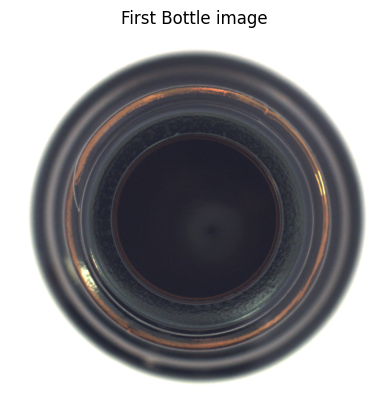

In [3]:
# Read first image and visulization
img=cv2.imread(train_good[0])
print('shape of image:',img.shape)

img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('First Bottle image')
plt.axis('off')
plt.show()

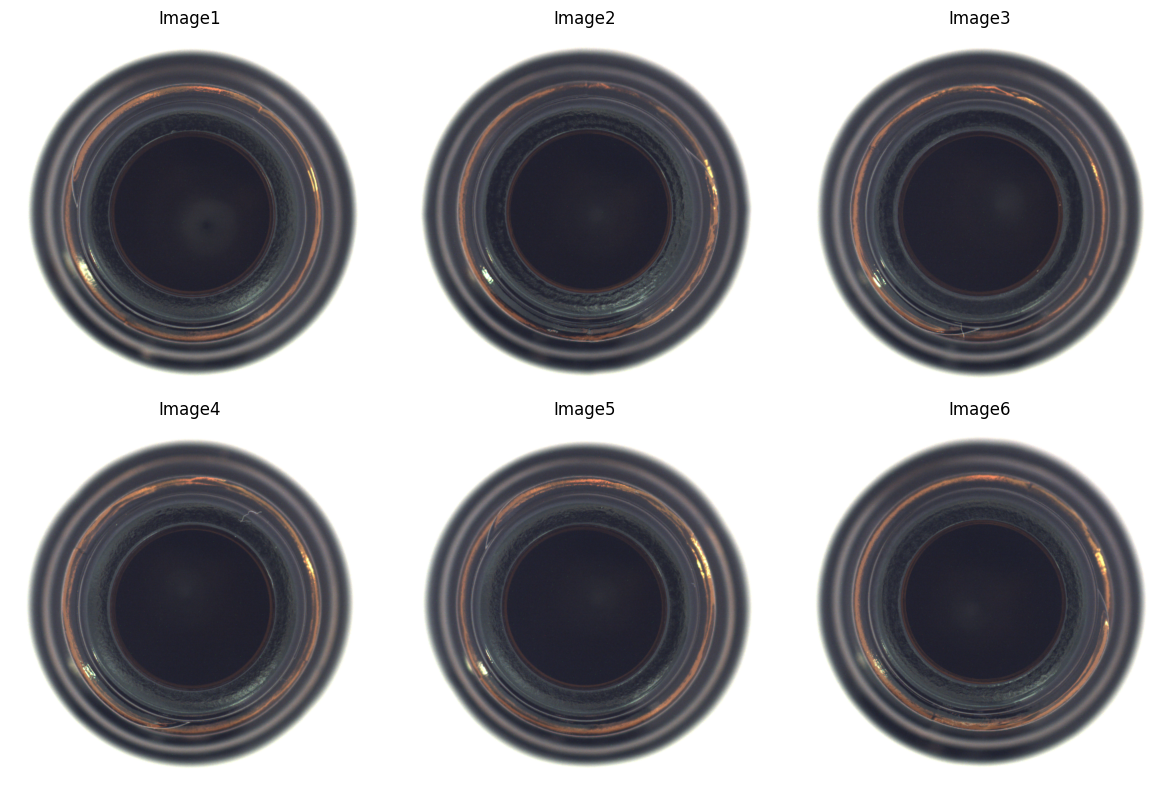

In [4]:
#read multipe image and visulization
plt.figure(figsize=(12,8))

for i in range(6):
    img=cv2.imread(train_good[i])
    img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img_rgb)
    plt.title(f'Image{i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
broken_large = glob('/kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/broken_large/*.png')
broken_small = glob('/kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/broken_small/*.png')
contamination = glob('/kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/contamination/*.png')

print("broken_large:", len(broken_large))
print("broken_small:", len(broken_small))
print("contamination:", len(contamination))

print("first broken_large image:", broken_large[0])
print("first broken_small image:", broken_small[0])
print("first contamination image:", contamination[0])

broken_large: 20
broken_small: 22
contamination: 21
first broken_large image: /kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/broken_large/007.png
first broken_small image: /kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/broken_small/007.png
first contamination image: /kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/contamination/007.png


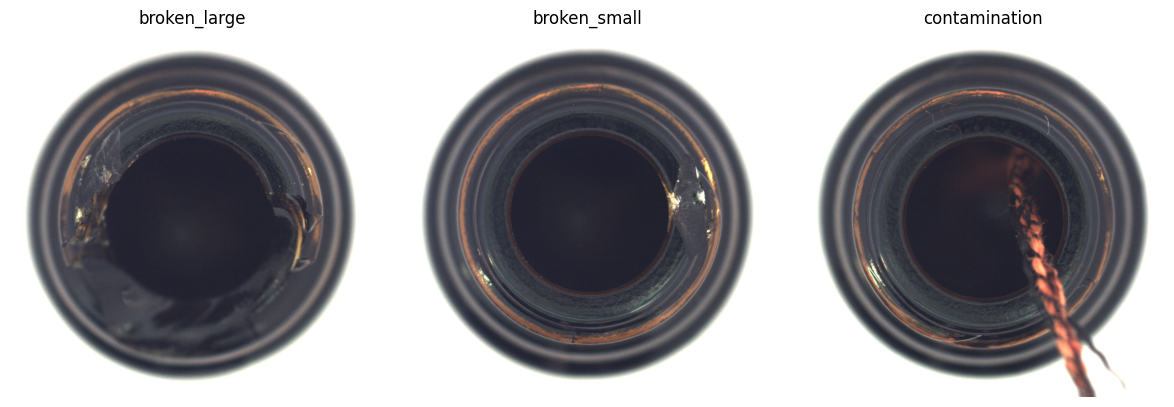

In [6]:
plt.figure(figsize=(12,4))

sample_defects = [broken_large[0], broken_small[0], contamination[0]]
titles = ['broken_large', 'broken_small', 'contamination']

for i in range(3):
    img = cv2.imread(sample_defects[i])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i+1)
    plt.imshow(img_rgb)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# combine all defect images into one list
defect_files = broken_large + broken_small + contamination

print("Number of broken_large images:", len(broken_large))
print("Number of broken_small images:", len(broken_small))
print("Number of contamination images:", len(contamination))
print("Total defect images:", len(defect_files))

print("First defect image path:", defect_files[0])

Number of broken_large images: 20
Number of broken_small images: 22
Number of contamination images: 21
Total defect images: 63
First defect image path: /kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/broken_large/007.png


In [8]:
good_files = train_good

print("Number of good images:", len(good_files))
print("Number of defect images:", len(defect_files))

print("First good image:", good_files[0])
print("First defect image:", defect_files[0])

Number of good images: 209
Number of defect images: 63
First good image: /kaggle/input/datasets/hashimalmaramhi/bottle/bottle/train/good/173.png
First defect image: /kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/broken_large/007.png


In [9]:
# create labels
good_labels=[0]*len(good_files)
defect_labels=[1]*len(defect_files)

print('Number of good labels',len(good_labels))
print('Number of defect labels:',len(defect_labels))

print('First 5 good labels:',good_labels[:5])
print('First 5 defect labels:',defect_labels[:5])

Number of good labels 209
Number of defect labels: 63
First 5 good labels: [0, 0, 0, 0, 0]
First 5 defect labels: [1, 1, 1, 1, 1]


In [10]:
# Combine all image paths
all_files=good_files+defect_files
# Combine all labels
all_labels=good_labels+defect_labels

print("Total images:", len(all_files))
print("Total labels:", len(all_labels))

print("First image path:", all_files[0])
print("First label:", all_labels[0])

print("Last image path:", all_files[-1])
print("Last label:", all_labels[-1])


Total images: 272
Total labels: 272
First image path: /kaggle/input/datasets/hashimalmaramhi/bottle/bottle/train/good/173.png
First label: 0
Last image path: /kaggle/input/datasets/hashimalmaramhi/bottle/bottle/test/contamination/014.png
Last label: 1


In [11]:
# Split Data TO Train and Test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    all_files,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
    
)
print('Traing image:',len(X_train))
print('Testing image',len(X_test))
print('Traing labels:',len(y_train))
print('Testing labels',len(y_test))

Traing image: 217
Testing image 55
Traing labels: 217
Testing labels 55


In [12]:
# Image preprocessing 
IMG_SIZE=224
def load_and_preprocess(image_paths):
    images=[]
    
    for path in image_paths:
        img=cv2.imread(path)
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img=img/255.0
        images.append(img)

    return np.array(images)
    

In [13]:
X_train_processed=load_and_preprocess(X_train)
X_test_processed=load_and_preprocess(X_test)

y_train=np.array(y_train)
y_test=np.array(y_test)

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (217, 224, 224, 3)
X_test shape: (55, 224, 224, 3)
y_train shape: (217,)
y_test shape: (55,)


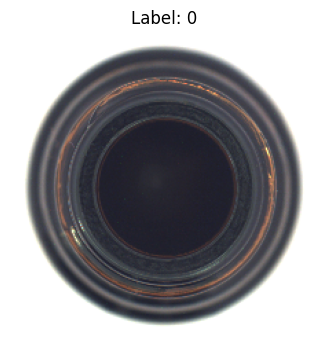

In [14]:
# visulize image after prprocessing
plt.figure(figsize=(4,4))
plt.imshow(X_train_processed[0])
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [15]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

2026-05-17 11:36:23.270211: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779017783.656306      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779017783.758567      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779017784.758643      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779017784.758686      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779017784.758689      23 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [18]:
history = model.fit(
    X_train_processed,
    y_train,
    epochs=20,
    validation_data=(X_test_processed, y_test),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20


I0000 00:00:1779017824.367674      77 service.cc:152] XLA service 0x7e6ca8004530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779017824.367726      77 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779017824.367733      77 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779017824.858931      77 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-17 11:37:07.747763: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 11:37:07.896863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8073 - loss: 1.3416

I0000 00:00:1779017830.469124      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7353 - loss: 1.2225 - val_accuracy: 0.7636 - val_loss: 0.5502
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7787 - loss: 0.5451 - val_accuracy: 0.7636 - val_loss: 0.5540
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7707 - loss: 0.5468 - val_accuracy: 0.7636 - val_loss: 0.5396
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7722 - loss: 0.5229 - val_accuracy: 0.7636 - val_loss: 0.5115
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6171 - loss: 0.6174 - val_accuracy: 0.7636 - val_loss: 0.5954
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7560 - loss: 0.5871 - val_accuracy: 0.7636 - val_loss: 0.4776
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8011 - loss: 0.4287 - val_accuracy: 0.8364 - val_loss: 0.3595
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8782 - loss: 0.3325 - val_accuracy: 0.8364 - val_loss: 0.3345
Epoch 9/20
7

In [19]:
test_loss, test_accuracy = model.evaluate(X_test_processed, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9532 - loss: 0.1598
Test Loss: 0.18906299769878387
Test Accuracy: 0.9454545378684998


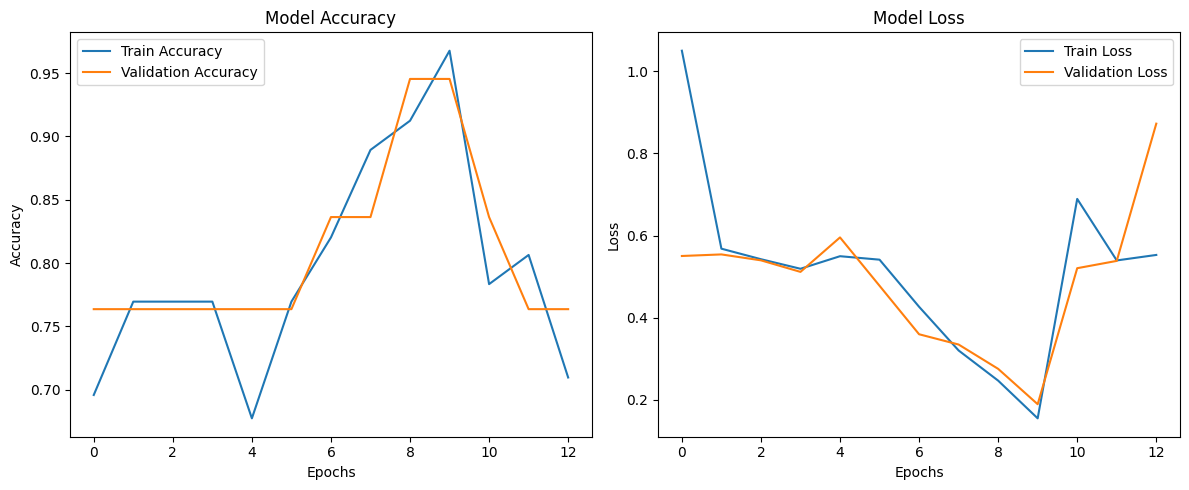

In [20]:
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 353ms/step


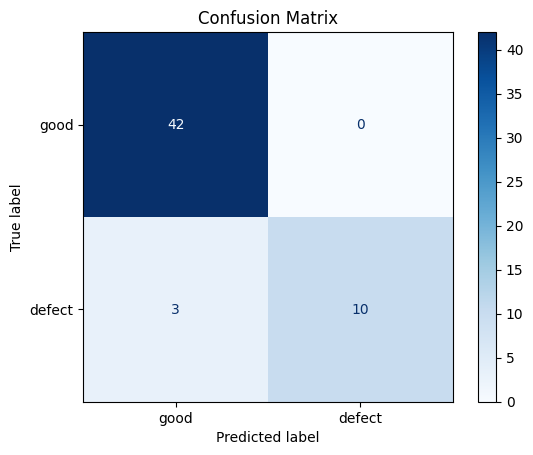

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# predict probabilities
y_pred_prob = model.predict(X_test_processed)

# convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'defect'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


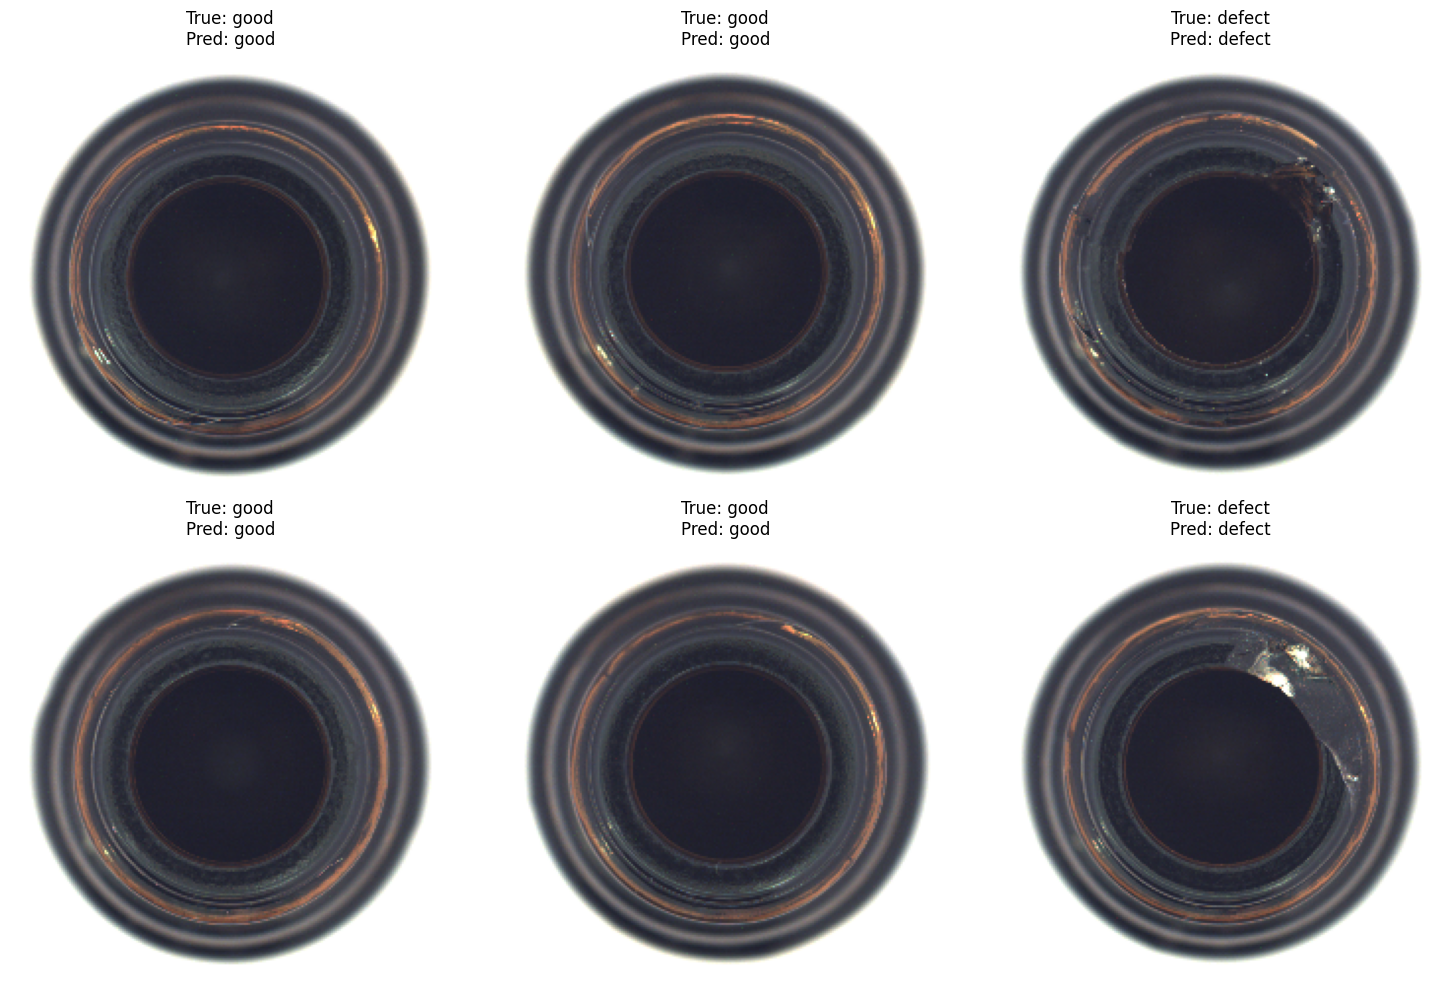

In [22]:
# predict probabilities
y_pred_prob = model.predict(X_test_processed)

# convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# class names
class_names = ['good', 'defect']

plt.figure(figsize=(15,10))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_test_processed[i])
    
    true_label = class_names[y_test[i]]
    predicted_label = class_names[y_pred[i]]
    
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()